# **Seasona Flu Prediction:**
## **Notebook 2: Exploratory Data Analysis:**
#### **CRISP-DM Framework: Data Understanding.**


### **Data Source:** National 2009 HINI Flu Survey.

### **Notebook Purpose:**
This Notebook conducts exploratory data anaylis on the cleaned dataset to ;
- Understand feauture distributions
- Identify relationships between feature and target variable 
- Detect outlier
- Genrate insights to inform modelling decisions in the Final Notebook

### **Notebook Inputs:**
-  `Data/Cleaned_data/cleaned_data.csv`

### **Notebook Outputs:**
- Visualizations saved to `Images/`
- Key insights to inform feature selection and modeling

## **Library Imports:**

In [1]:
# Overall Imports to be used throughout the analysis

#Standard Libraries
import warnings
warnings.filterwarnings("ignore")

#Core Data Manipulation Libraries
import numpy as np
import pandas as pd

#Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("All libraries imported successfully and ready to use")

All libraries imported successfully and ready to use


## **Loading Cleaned Data:**


In [2]:
#Define paths for data and images
cleaned_path = "../Data/Cleaned_data/"
images_path = "../Images/"

#Load the Cleaned Data:
# Load cleaned data
df = pd.read_csv(cleaned_path + "cleaned_data.csv", 
                 index_col="respondent_id")

# Separate numeric and categorical columns
# Exclude target variable seasonal_vaccine to prevent data leakage during preprocessing
numeric_cols = df.select_dtypes(
    include=["float64", "int64"]
).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "seasonal_vaccine"]

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f" Cleaned data loaded successfully")
print(f"  Shape               : {df.shape}")
print(f"  Numeric Features    : {len(numeric_cols)}")
print(f"  Categorical Features: {len(categorical_cols)}")
print(f"  Target              : seasonal_vaccine")



 Cleaned data loaded successfully
  Shape               : (26707, 36)
  Numeric Features    : 23
  Categorical Features: 12
  Target              : seasonal_vaccine


## **Exploratory Data Analysis:**


### **Feature Distribution:**
I examined the distribution of each feature group separately;
- Behavioral features
- Opinion features
- Demographic features

#### **Behavioral Features:**
Behavioral feauture capture protective actions takes by respondents. 
All behavioral features are binary (0=No, 1=Yes)
I examine their distributions and skewness to understand compliance patttersn across survey population.

In [9]:
#Behavorial Features Skewness Analsysis

#Calculate skewness for each behavioral feature
# Skewness > 1 or < -1 indicates high skewness
# Skewness between -1 and 1 indicates moderate or no skewness
behavioral_skewness = df[behavioral_cols].skew().round(2)

print(" Behavioral Features Skewness")
for col, skew in behavioral_skewness.items():
    if abs(skew) > 1:
        level = "High Skewness"
    elif abs(skew) > 0.5:
        level = "Moderate Skewness"
    else:
        level = "Low Skewness"
    print(f"  {col:<35} : {skew:>6} ({level})")

 Behavioral Features Skewness
  behavioral_antiviral_meds           :   4.19 (High Skewness)
  behavioral_avoidance                :  -1.01 (High Skewness)
  behavioral_face_mask                :    3.4 (High Skewness)
  behavioral_wash_hands               :  -1.72 (High Skewness)
  behavioral_large_gatherings         :   0.59 (Moderate Skewness)
  behavioral_outside_home             :   0.69 (Moderate Skewness)
  behavioral_touch_face               :  -0.76 (Moderate Skewness)


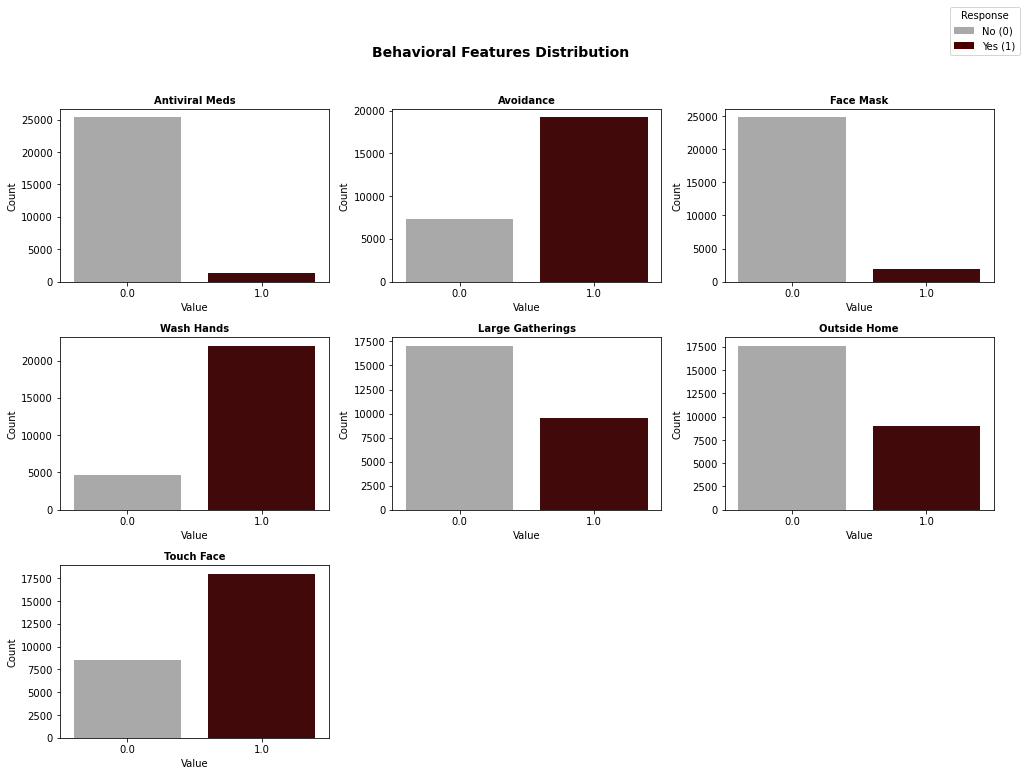

In [10]:
#Behavioral Features Distribution

#Extract only behavioral columns fromnuemric features for focuse analysis
behavioral_cols = [col for col in numeric_cols if col.startswith("behavioral")]

#Creat a grid of histogram subplots one for each behavioral feature to visualize their distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten() #Flatten axes array for easy iteration

# Plot count of each behavioral feature
for i, col in enumerate(behavioral_cols):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        palette=["#A9A9A9", "#4A0000"]
    )
#clean up column names for readable title
    axes[i].set_title(col.replace("behavioral_", "").replace("_", " ").title(),
                      fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

# Hide any unused subplots since we have 7 features in a 3*3 grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Behavioral Features Distribution",
             fontsize=14, fontweight="bold", y=1.02)
# Add single legend for entire figure
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#A9A9A9", label="No (0)"),
    Patch(facecolor="#4A0000", label="Yes (1)")
]
fig.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=10,
    title="Response",
    bbox_to_anchor=(1.02, 1)  # Place outside figure to the right
)
plt.tight_layout()
plt.savefig(images_path + "behavioral_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Behavioral Features Observations:
- All behavioral features are binary (0 = No, 1 = Yes) as expected
- **High compliance behaviors:** Wash hands, avoidance and 
  touch face show majority positive behavior (skewed to 1)
- **Low compliance behaviors:** Antiviral meds and face mask 
  show very low uptake (skewed to 0)
- High skewness in antiviral meds and face mask suggests 
  these may have limited predictive power
- No unexpected values detected in any behavioral feature


#### **Opinion Features:**
Opinion features capture respondents views on vaccine 
effectiveness, disease risk and worry about side effects.
These features are ordinal ranging from 1 to 5.
I examine their distributions to understand general 
sentiment across the survey population.


H1N1 Opinion Features     : ['opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc']
Seasonal Opinion Features : ['opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc']
 Seasonal Opinion Features Skewness
  opinion_seas_vacc_effective         :  -1.32 (High Skewness)
  opinion_seas_risk                   :   0.25 (Low Skewness)
  opinion_seas_sick_from_vacc         :   0.92 (Moderate Skewness)


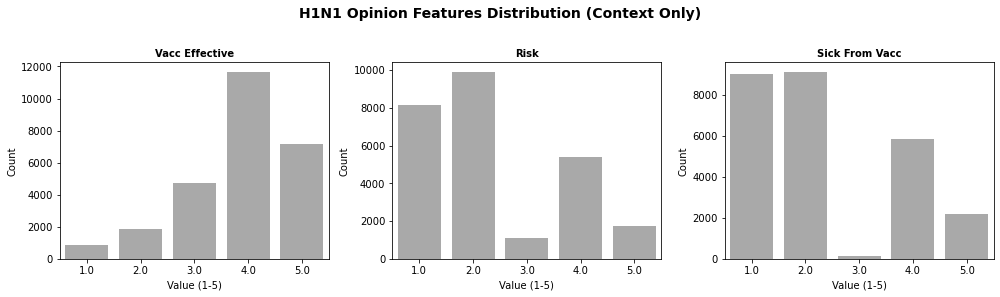

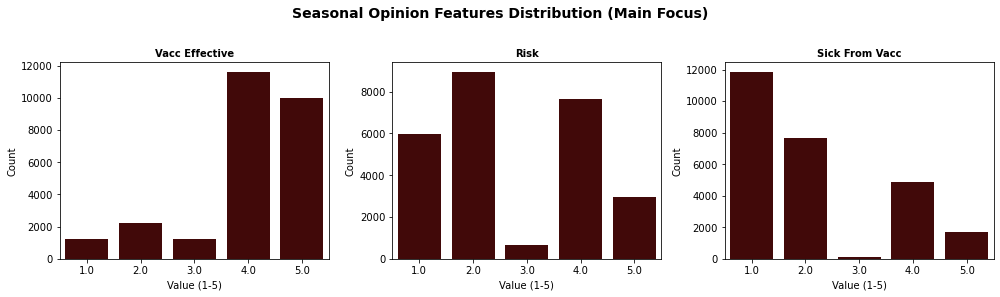

In [13]:

# Opinion Features Distribution


# Extract only opinion columns from numeric features for focused analysis
opinion_cols = [col for col in numeric_cols if col.startswith("opinion")]

# Separate H1N1 and seasonal opinion columns for focused analysis since i am only focusing on the data for seasonal flu
h1n1_opinion_cols = [col for col in opinion_cols if "h1n1" in col]
seas_opinion_cols = [col for col in opinion_cols if "seas" in col]

print(f"H1N1 Opinion Features     : {h1n1_opinion_cols}")
print(f"Seasonal Opinion Features : {seas_opinion_cols}")

# Calculate skewness for seasonal opinion features
seas_opinion_skewness = df[seas_opinion_cols].skew().round(2)

print(" Seasonal Opinion Features Skewness")
for col, skew in seas_opinion_skewness.items():
    if abs(skew) > 1:
        level = "High Skewness"
    elif abs(skew) > 0.5:
        level = "Moderate Skewness"
    else:
        level = "Low Skewness"
    print(f"  {col:<35} : {skew:>6} ({level})")

# ── Figure 1: H1N1 Opinion Features (context/comparison) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

for i, col in enumerate(h1n1_opinion_cols):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        color="#A9A9A9"    # Grey for H1N1 - not our main focus
    )
    axes[i].set_title(
        col.replace("opinion_h1n1_", "").replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Value (1-5)")
    axes[i].set_ylabel("Count")

plt.suptitle("H1N1 Opinion Features Distribution (Context Only)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "h1n1_opinion_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Seasonal Opinion Features (main focus) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

for i, col in enumerate(seas_opinion_cols):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        color="#4A0000"    # Dark maroon for seasonal - our main focus
    )
    axes[i].set_title(
        col.replace("opinion_seas_", "").replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Value (1-5)")
    axes[i].set_ylabel("Count")

plt.suptitle("Seasonal Opinion Features Distribution (Main Focus)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "seas_opinion_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Seasonal Opinion Features Observations:

Seasonal Vaccine Effectiveness (Seas Vacc Effective):
- Majority of respondents believe the seasonal vaccine is 
  effective (values 4 and 5 dominate)
- Very few respondents believe it is not effective (values 1 and 2)
- This is a positive signal — high perceived effectiveness 
  may correlate with higher vaccination uptake

Seasonal Risk (Seas Risk):
- Most respondents perceive low to moderate risk of getting 
  sick without the vaccine (values 1 and 2 dominate)
- Value 3 (Don't know) has very few responses
- Moderate uptick at value 4 suggesting some respondents 
  do perceive meaningful risk
- Low perceived risk may explain why some people choose 
  not to vaccinate

Seasonal Sick From Vaccine (Seas Sick From Vacc):
- Majority of respondents are not worried about getting 
  sick from the vaccine (value 1 dominates strongly)
- Worry decreases as the scale increases
- Low worry about side effects is a positive signal for 
  vaccination uptake

Overall Observation:
- Respondents generally have positive opinions about the 
  seasonal vaccine
- Perceived effectiveness and low worry about side effects 
  are likely strong predictors of vaccination
- These features will be closely watched during modeling 
  for feature importance


### **Demographic Features:**
Demographic features capture the background characteristics 
of respondents including age, education, race, sex, income 
and employment status. These are all categorical features.
We examine their distributions to understand the composition 
of the survey population.


Demographic Features Value Counts

age_group:
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: age_group, dtype: int64

education:
College Graduate    10097
Some College         7043
12 Years             5797
< 12 Years           2363
Name: education, dtype: int64

race:
White                21222
Black                 2118
Hispanic              1755
Other or Multiple     1612
Name: race, dtype: int64

sex:
Female    15858
Male      10849
Name: sex, dtype: int64

income_poverty:
<= $75,000, Above Poverty    12777
> $75,000                     6810
Below Poverty                 2697
Name: income_poverty, dtype: int64

marital_status:
Married        13555
Not Married    11744
Name: marital_status, dtype: int64

rent_or_own:
Own     18736
Rent     5929
Name: rent_or_own, dtype: int64

employment_status:
Employed              13560
Not in Labor Force    10231
Unemployed             1453
Name: employment_status, dtype: int64

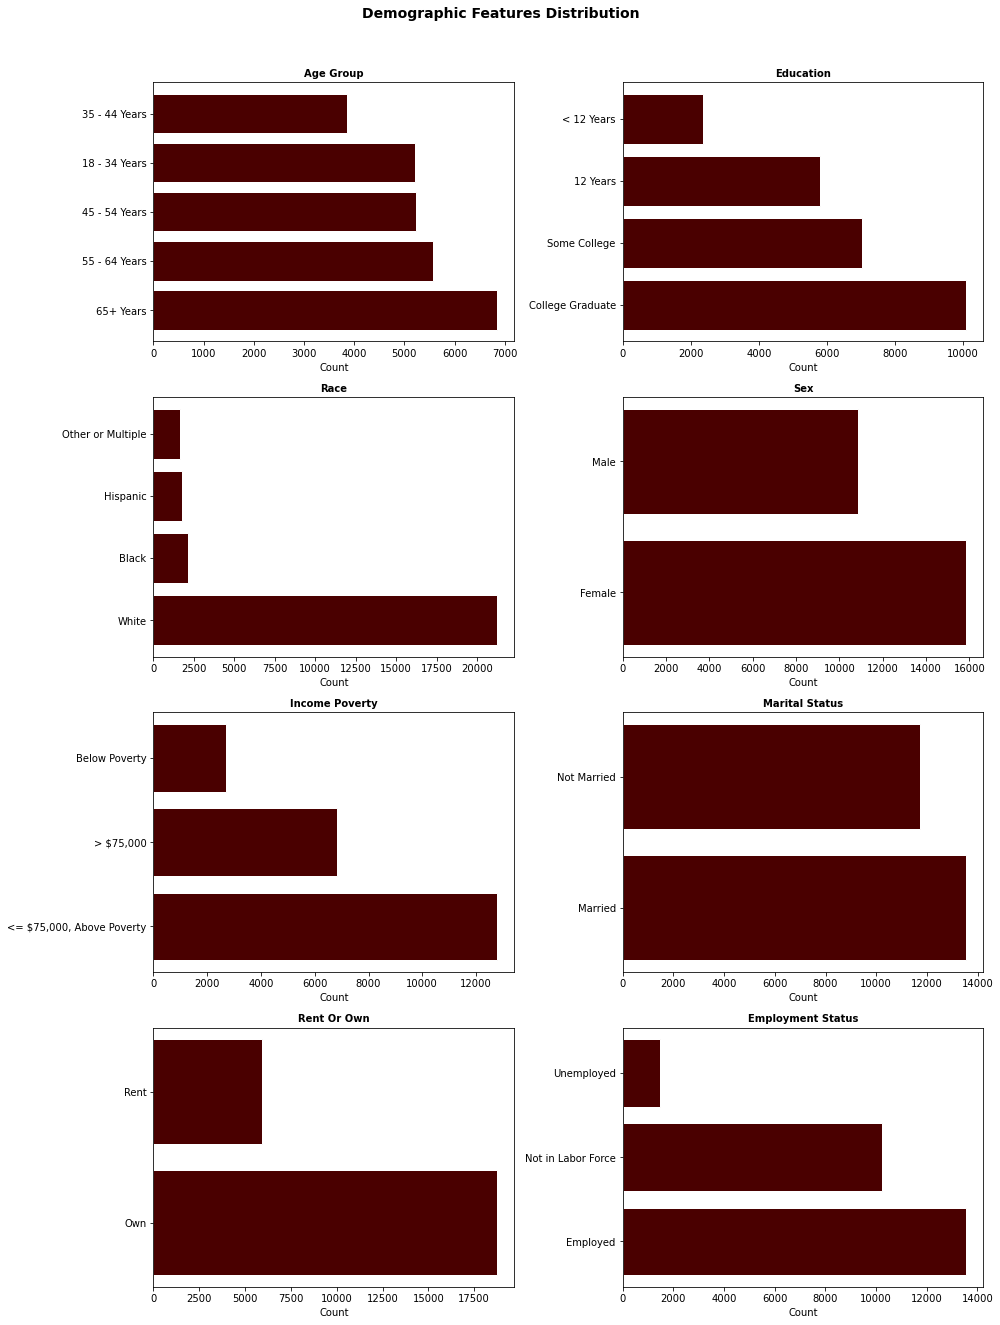

In [14]:
# DEmographic Features Analysis

# Define demographic columns
demographic_cols = [
    "age_group", "education", "race", "sex",
    "income_poverty", "marital_status",
    "rent_or_own", "employment_status"
]

# Calculate value counts for each demographic feature
print("Demographic Features Value Counts")
for col in demographic_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Create a grid of subplots one for each demographic feature
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

# Plot count of each demographic feature
for i, col in enumerate(demographic_cols):
    value_counts = df[col].value_counts()
    
    axes[i].barh( #Horizonatal bar chart for better readability of category names
        value_counts.index,
        value_counts.values,
        color="#4A0000",
        edgecolor="white"
    )
    # Clean up column name for readable title
    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.suptitle("Demographic Features Distribution",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "demographic_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Demographic Features Observations

Age Group:
- Older respondents dominate the survey population
- 65+ years is the largest group (6,843) followed by 55-64 years (5,563)
- Younger respondents 18-34 years are underrepresented (5,215)
- This is relevant as older populations are higher risk for 
  flu complications and may be more likely to vaccinate

Education:
- College graduates are the largest group (10,097)
- Less than 12 years education is the smallest group (2,363)
- Higher education levels dominate the survey population
- Education level may influence health literacy and 
  vaccination decisions

Race:
- White respondents dominate heavily (21,222 out of 26,707)
- This is a significant limitation of the dataset as it 
  may not represent diverse populations equally
- Results should be interpreted with caution across 
  racial groups

Sex:
- Female respondents outnumber male (15,858 vs 10,849)
- Roughly 59% female and 41% male

Income Poverty:
- Majority are above poverty level (12,777)
- Only 2,697 respondents are below poverty
- Income level may influence access to healthcare and 
  vaccination

Marital Status:
- Fairly balanced between married (13,555) and 
  not married (11,744)

Rent or Own:
- Majority own their home (18,736 vs 5,929 renters)
- Home ownership may be a proxy for socioeconomic stability

Employment Status:
- Employed respondents are the largest group (13,560)
- Not in labor force is second (10,231) which aligns with 
  the older age distribution
- Unemployed is the smallest group (1,453)

Overall Observation:
- The survey population skews older, white, educated 
  and above poverty
- These demographic imbalances are important limitations 
  to acknowledge when applying findings to the 
  Kenyan public health context
- Age and education are likely strong demographic 
  predictors of seasonal flu vaccination

### **Outlier Detection:**
I examine numeric features for outliers using boxplots.
Outliers can affect model performance and will be treated/imputed in the Final Notebook after the train test split

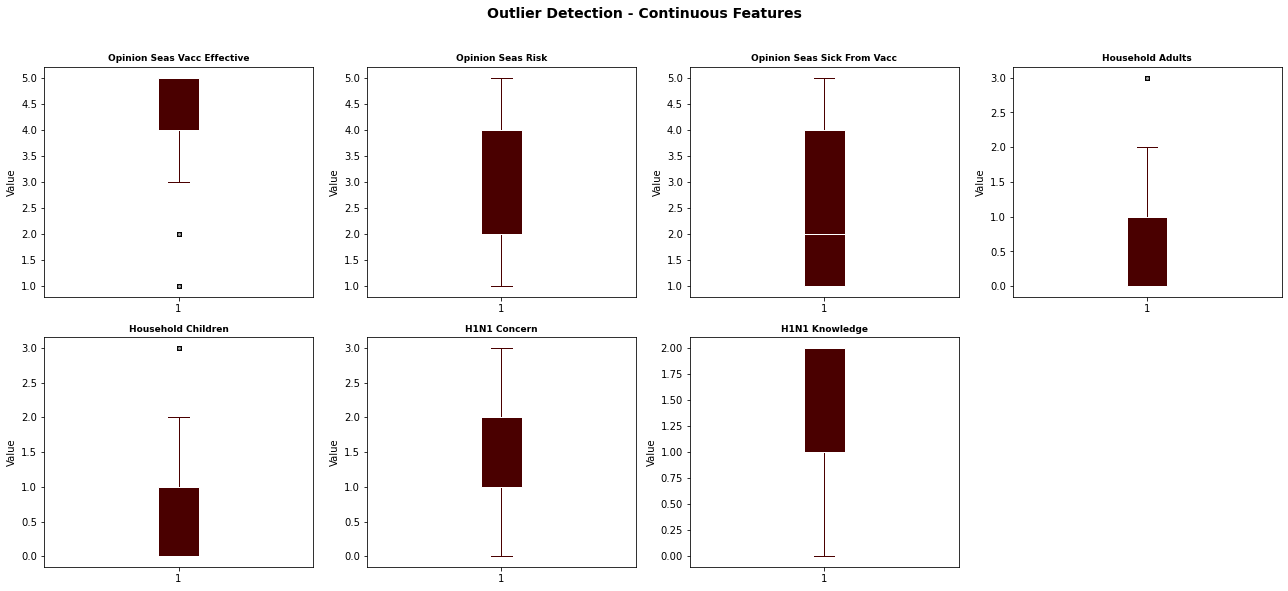

Outlier Summary (IQR Method)
  opinion_seas_vacc_effective         : 3427 outliers
  opinion_seas_risk                   : 0 outliers
  opinion_seas_sick_from_vacc         : 0 outliers
  household_adults                    : 1125 outliers
  household_children                  : 1747 outliers
  h1n1_concern                        : 0 outliers
  h1n1_knowledge                      : 0 outliers


In [17]:
#Outlier Detection

# Focus on continuous numeric features only as binary features cannot have outliers by definition
continuous_cols = [
    "opinion_seas_vacc_effective",
    "opinion_seas_risk",
    "opinion_seas_sick_from_vacc",
    "household_adults",
    "household_children",
    "h1n1_concern",        # may correlate with seasonal vaccine
    "h1n1_knowledge"       #may also correlate with seasonal vaccine since they are related topics
]

# Create boxplots for continuous features
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="#4A0000", color="white"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="#4A0000"),
        capprops=dict(color="#4A0000"),
        flierprops=dict(
            marker="o",
            markerfacecolor="#A9A9A9",
            markersize=4
        )
    )
    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=9, fontweight="bold"
    )
    axes[i].set_ylabel("Value")
#Hide any unused subplots since we have 7 features in a 2*4 grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Outlier Detection - Continuous Features",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "outlier_detection.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print outlier summary using IQR method
print("Outlier Summary (IQR Method)")
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"  {col:<35} : {outliers} outliers")

####  Outlier Detection Observations

Opinion Seas Vacc Effective (3,427 outliers):
- High number of statistical outliers detected
- However these are NOT true outliers — they represent 
  legitimate survey responses
- The distribution is left skewed meaning most respondents 
  rate the vaccine as effective (4 and 5)
- Lower values (1 and 2) appear as statistical outliers 
  but represent genuine minority opinions


Household Adults (1,125 outliers):
- Most respondents live with 0 or 1 other adult
- Households with 2 or 3 adults are flagged as statistical 
  outliers but are perfectly valid living arrangements
- Top coded at 3 meaning no value exceeds 3


Household Children (1,747 outliers):
- Majority of respondents have no children in the household
- Respondents with 1 or more children are flagged as 
  statistical outliers
- Top coded at 3 meaning no value exceeds 3
- This aligns with the older age distribution of the 
  survey population where children have left home


Opinion Seas Risk (0 outliers):
- No outliers detected
- Distribution is fairly spread across all values
- Respondents have varied opinions about seasonal flu risk

Opinion Seas Sick From Vacc (0 outliers):
- No outliers detected
- Most respondents are not worried about getting sick 
  from the vaccine
- Distribution skews towards lower worry values

H1N1 Concern (0 outliers):
- No outliers detected
- Concern levels are fairly distributed across the scale
- Kept for analysis as general flu awareness may correlate 
  with seasonal vaccination behavior

H1N1 Knowledge (0 outliers):
- No outliers detected
- Knowledge levels are distributed across the scale
- Kept for analysis as general flu knowledge may correlate 
  with seasonal vaccination behavior

Overall Outlier Strategy:
- I did not perform any aggressive outlier removal in thr Final Notebook as the outliers were genuine survey responses hence valid data points
- All flagged values represent legitimate survey responses
- The IQR method flags values in skewed distributions 
  as outliers even when they are valid
- Scaling in the Final notebook handles distribution 
  differences between features
- This decision protects the integrity of the survey data 
  and avoids removing genuine minority opinions and 
  living situations that may be important predictors 
  of vaccination behavior

## **Feature Vs Target Analysis:**
I examined how each feature relates to our target variable 'seasonal_vaccine'. This helped me to understand which features are likely to be strong predictors during modeling.

I examined three feature groups:
1. Behavioral features vs seasonal vaccine
2. Opinion features vs seasonal vaccine
3. Demographic features vs seasonal vaccine

#### **Behavorial features vs Seasonal vaccine:**
